In [24]:
import numpy as np
import matplotlib.pyplot as plt
try:
    # This is robust against converting to a python script and running outside
    # of a jupyter notebook, where the %config magic command would fail.
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

import mitsuba as mi
import drjit as dr

mi.set_variant('cuda_acoustic', 'llvm_acoustic', 'cuda_ad_acoustic', 'llvm_ad_acoustic')
print(f'Using variant: {mi.variant()}')
mi.set_log_level(mi.LogLevel.Warn)

from mitsuba import ScalarTransform4f as tf

Using variant: llvm_ad_acoustic


# Rendering with Atmospheric Data

<div class="admonition important alert alert-block alert-info">

💡 **Info:**

This tutorial demonstrates misuka's atmospheric-data-aware forward rendering. The speed of sound and the frequency-dependent air attenuation (ISO 9613-1) both depend on the state of the propagation medium (temperature, humidity, pressure, ...). This notebook covers the **two** implemented ways of taking that into account, and shows how to meaningfully compare the results against each other and against a rendering that ignores atmospheric conditions entirely.

</div>

<div class="admonition important alert alert-block alert-success">

🚀 **You will learn how to:**

<ul>
  <li>Compute the speed of sound and the ISO 9613-1 air attenuation coefficient from atmospheric parameters</li>
  <li>Apply atmospheric attenuation as a <b>post-processing</b> step on a rendered ETC</li>
  <li>Let the <code>acoustic_path</code> integrator apply atmospheric attenuation <b>during</b> rendering, using the <code>medium</code> plugin parameter</li>
  <li>Correctly compare renders that used different speeds of sound, by aligning their time axes on path <i>distance</i> rather than raw time bin</li>
</ul>

</div>

## Scene setup

We reuse the shoebox room from the [Shoebox scene tutorial](../shoebox_scene.ipynb) — see that notebook for a full walkthrough of the scene-building API. The short version: six absorptive/scattering walls built from `rectangle` shapes and an `acousticbsdf`, wrapped around a spherical sound source.

In [25]:
room_dim       = np.array([6, 8, 4.0]) # length, width, height
emitter_pos    = np.array([3, 6, 1.2])
receiver_pos   = np.array([2, 1, 1.2])
emitter_radius = 0.5

absorption_top     = [(100, 0.1), (500, 0.5), (20000, 0.1)]
scattering_top     = [(100, 0.3), (500, 0.5), (20000, 0.8)]

absorption_bottom  = [(100, 0.4), (500, 0.5), (20000, 0.5)]
scattering_bottom  = [(100, 0.3), (500, 0.6), (20000, 0.9)]

absorption_left    = [(100, 0.0), (500, 0.4), (20000, 0.6)]
scattering_left    = [(100, 0.2), (500, 0.3), (20000, 0.4)]

absorption_right   = [(100, 0.2), (500, 0.4), (20000, 0.5)]
scattering_right   = [(100, 0.3), (500, 0.5), (20000, 0.8)]

absorption_front   = [(100, 0.3), (500, 0.7), (20000, 0.2)]
scattering_front   = [(100, 0.1), (500, 0.2), (20000, 0.3)]

absorption_back    = [(100, 0.7), (500, 0.8), (20000, 0.9)]
scattering_back    = [(100, 0.2), (500, 0.4), (20000, 0.6)]

scene_dict = {
    'type': 'scene',
    'emitter': {
        'type': 'sphere',
        'radius': 0.1,
        'center': emitter_pos,
        'emitter': {
            'type': 'area',
            'radiance': {'type': 'uniform', 'value': 50},
        },
    },
}

surfaces = ['top', 'bottom', 'left', 'right', 'front', 'back']
absorption_values = [absorption_top,   absorption_bottom,
                     absorption_left,  absorption_right,
                     absorption_front, absorption_back]
scattering_values = [scattering_top,   scattering_bottom,
                     scattering_left,  scattering_right,
                     scattering_front, scattering_back]

for surface, scattering, absorption in zip(surfaces, scattering_values, absorption_values):
    scene_dict[f'bsdf_{surface}'] = {
        'type': 'acousticbsdf',
        'absorption': {'type': 'spectrum', 'value': absorption},
        'scattering': {'type': 'spectrum', 'value': scattering},
        'specular_lobe_width': 0.001,
    }

scene_dict['cube'] = {
    'type': 'shapegroup',
    'top':    {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_top'},
               'to_world': tf().translate([0, 0, 1]).scale(0.5).translate([1, 1, 0]), 'flip_normals': True},
    'bottom': {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_bottom'},
               'to_world': tf().scale(0.5).translate([1, 1, 0.])},
    'left':   {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_left'},
               'to_world': tf().rotate(axis=[0, -1, 0], angle=90).scale(0.5).translate([1, 1, 0.]), 'flip_normals': True},
    'right':  {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_right'},
               'to_world': tf().translate([1, 0, 1]).rotate(axis=[0., 1., 0.], angle=90).scale(0.5).translate([1, 1, 0.]), 'flip_normals': True},
    'front':  {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_front'},
               'to_world': tf().rotate(axis=[1, 0, 0], angle=90).scale(0.5).translate([1, 1, 0.]), 'flip_normals': True},
    'back':   {'type': 'rectangle', 'bsdf': {'type': 'ref', 'id': 'bsdf_back'},
               'to_world': tf().translate([0, 1, 0]).rotate(axis=[1., 0., 0.], angle=90).scale(0.5).translate([1, 1, 0.])},
}

scene_dict['shoebox'] = {
    'type': 'instance',
    'geometry': {'type': 'ref', 'id': 'cube'},
    'to_world': tf().scale(room_dim),
}

scene = mi.load_dict(scene_dict)

## Baseline: rendering without atmospheric data

First, a reference rendering that ignores atmospheric conditions entirely, using the default `speed_of_sound = 343` m/s and no air attenuation. This is the same baseline every acoustic scene uses unless you opt into one of the two atmospheric approaches below.

In [26]:
max_time = 0.3        # maximum propagation time to simulate, in seconds
sampling_rate = 5000  # time bins per second
time_bins = int(max_time * sampling_rate)

rendered_frequencies = [100, 500, 20000]  # must stay within the range of the material spectra defined above
rendered_frequencies_str = ', '.join(map(str, rendered_frequencies))

spp = 2**20  # rays per frequency

microphone = mi.load_dict({
    'type': 'microphone',
    'origin': receiver_pos,
    'direction': emitter_pos,
    'film': {
        'type': 'tape',
        'frequencies': rendered_frequencies_str,
        'time_bins': time_bins,
    },
})

integrator_acoustic = mi.load_dict({
    'type': 'acoustic_path',
    'max_depth': -1,
    'max_time': max_time,
})

etc = mi.render(scene, sensor=microphone, integrator=integrator_acoustic, spp=spp)

## Two ways of using atmospheric data

Both approaches start from the same set of atmospheric parameters and the same helper, [`mitsuba.acoustic.speed_of_sound`](../shoebox_scene.ipynb), to turn them into a speed of sound. They differ in **when** and **how** the frequency-dependent air attenuation (ISO 9613-1) gets applied:

1. **Post-processing** — render at the atmospheric speed of sound, then attenuate the finished ETC with [`mitsuba.acoustic.apply_pure_tone_attenuation`](../shoebox_scene.ipynb). The attenuation is computed from each *time bin's* implied distance (`distance = time * speed_of_sound`).
2. **Inline (integrator-side)** — pass the atmospheric parameters directly to the `acoustic_path` integrator via its `medium` parameter, with `apply_attenuation=True` (the default once `medium` is set). The integrator computes the speed of sound internally and attenuates every path contribution using its true accumulated *geometric* path distance, before it is binned in time. This avoids the time-bin quantization inherent to the post-processing approach and is generally more accurate.

### Approach 1: post-processing

In [27]:
# Parameters describing the propagation medium (air)
temperature = 25.0    # degrees Celsius
relative_humidity = 0.6      # in the range [0, 1]
atmospheric_pressure = 101825.0  # Pascal
saturation_vapor_pressure = 610.78 * 10 ** (7.5 * temperature / (temperature + 237.3))  # Pascal
co2_ppm = 400.0     # parts per million

speed_method = 'auto'  # available: 'auto', 'simple', 'ideal_gas', 'cramer'

speed_of_sound_atmo = mi.acoustic.speed_of_sound(
    temperature=temperature,                             # must be provided
    relative_humidity=relative_humidity,                  # optional
    atmospheric_pressure=atmospheric_pressure,             # optional
    saturation_vapor_pressure=saturation_vapor_pressure,   # optional
    co2_ppm=co2_ppm,                                       # optional
    method=speed_method)

print(f'speed_of_sound_atmo = {speed_of_sound_atmo:.3f} m/s (vs. the default 343 m/s)')

integrator_acoustic_atmo_post = mi.load_dict({
    'type': 'acoustic_path',
    'speed_of_sound': speed_of_sound_atmo,
    'max_depth': -1,
    'max_time': max_time,
})

# Render without attenuation first...
etc_atmo_post_raw = mi.render(scene, sensor=microphone, integrator=integrator_acoustic_atmo_post, spp=spp)

# ...then apply air attenuation to the finished ETC as a post-processing step.
etc_atmo_post = mi.acoustic.apply_pure_tone_attenuation(
    etc=etc_atmo_post_raw,
    sampling_rate=sampling_rate,
    speed_of_sound_ms=speed_of_sound_atmo,
    temperature=temperature,
    frequencies=rendered_frequencies,
    relative_humidity=relative_humidity,
    atmospheric_pressure=atmospheric_pressure,
)

speed_of_sound_atmo = 347.289 m/s (vs. the default 343 m/s)


### Approach 2: inline rendering

Instead of computing the speed of sound in Python and attenuating afterwards, the same atmospheric parameters can be handed directly to the integrator via its `medium` parameter. Note that we do **not** set `speed_of_sound` here — leaving it unset makes the integrator derive it from `medium` internally (using `speed_method`, same as above). If `speed_of_sound` *is* set explicitly, it always wins, regardless of `medium`.

In [29]:
integrator_acoustic_atmo_auto = mi.load_dict({
    'type': 'acoustic_path',
    # 'speed_of_sound': ...,  # if set, this would override the value derived from 'medium'
    'medium': {
        'temperature': temperature,                            # must be provided
        'relative_humidity': relative_humidity,                # optional
        'atmospheric_pressure': atmospheric_pressure,           # optional
        'saturation_vapor_pressure': saturation_vapor_pressure, # optional
        'co2_ppm': co2_ppm,                                     # optional
    },
    'speed_method': speed_method,
    'apply_attenuation': True,  # default once 'medium' is set; set False to only use 'medium' for the speed of sound
    'max_depth': -1,
    'max_time': max_time,
})
print(integrator_acoustic_atmo_auto)

etc_atmo_auto = mi.render(scene, sensor=microphone, integrator=integrator_acoustic_atmo_auto, spp=spp)

AcousticPathIntegrator[
  speed_of_sound = 347.289
  max_time = 0.3
  max_depth = disabled
  rr_depth = 100000
  max_energy_loss = 60.000000 dB
  hide_emitters = 0
  apply_attenuation = 1
]


## Comparing the results

We reuse two small helpers to plot an ETC in dB and the relative difference between two ETCs in percent.

In [30]:
def plot_etc(etc: mi.TensorXf, sampling_rate, max_time,
             dB=True, normalize=True, bottom=-70, *args, **kwargs):
    """Plot Energy Time Curve"""
    times = np.arange(max_time, step=1/sampling_rate)
    # .numpy() aliases the TensorXf's own memory, so an in-place normalization
    # would otherwise silently corrupt the caller's tensor. Copy first so this
    # function is read-only w.r.t. its input.
    etc = etc.numpy().copy().squeeze()

    plt.xlabel('Time in s')
    plt.ylabel('Amplitude')

    if normalize:
        etc /= np.max(etc)

    if dB:
        with np.errstate(divide='ignore'):
            etc = 10 * np.nan_to_num(np.log10(np.abs(etc)), neginf=-300)
        plt.ylabel('Amplitude in dB')

    plt.plot(times, etc, *args, **kwargs)
    plt.xlim(0, max_time)
    plt.ylim(bottom=bottom, top=np.max(etc) + 5)


def _as_numpy(etc):
    """Accepts either a mi.TensorXf or a plain numpy array (e.g. the output
    of resample_to_reference_speed below)."""
    if hasattr(etc, 'numpy'):
        return etc.numpy().copy().squeeze()
    return np.asarray(etc).squeeze()


def plot_etc_diff_relative(etc1, etc2, sampling_rate, max_time, *args, **kwargs):
    """Plot relative difference of two Energy Time Curves in percent.

    Divides by max(|etc1|, |etc2|) rather than etc2 alone: attenuation can
    drive etc2 towards zero (especially at high frequencies, over distance),
    and dividing by a near-zero reference blows the percentage up towards
    +/-inf for no physically meaningful reason. Normalizing by whichever of
    the two is larger keeps the result bounded to +/-100% and well-defined
    even when one curve has decayed to (numerical) zero.
    """
    times = np.arange(max_time, step=1/sampling_rate)
    etc1 = _as_numpy(etc1)
    etc2 = _as_numpy(etc2)

    with np.errstate(divide='ignore', invalid='ignore'):
        reference = np.maximum(np.abs(etc1), np.abs(etc2))
        diff = np.nan_to_num((etc1 - etc2) / reference * 100)

    plt.xlabel('Time in s')
    plt.ylabel('Relative difference in %')
    plt.plot(times, diff, *args, **kwargs)
    plt.xlim(0, max_time)

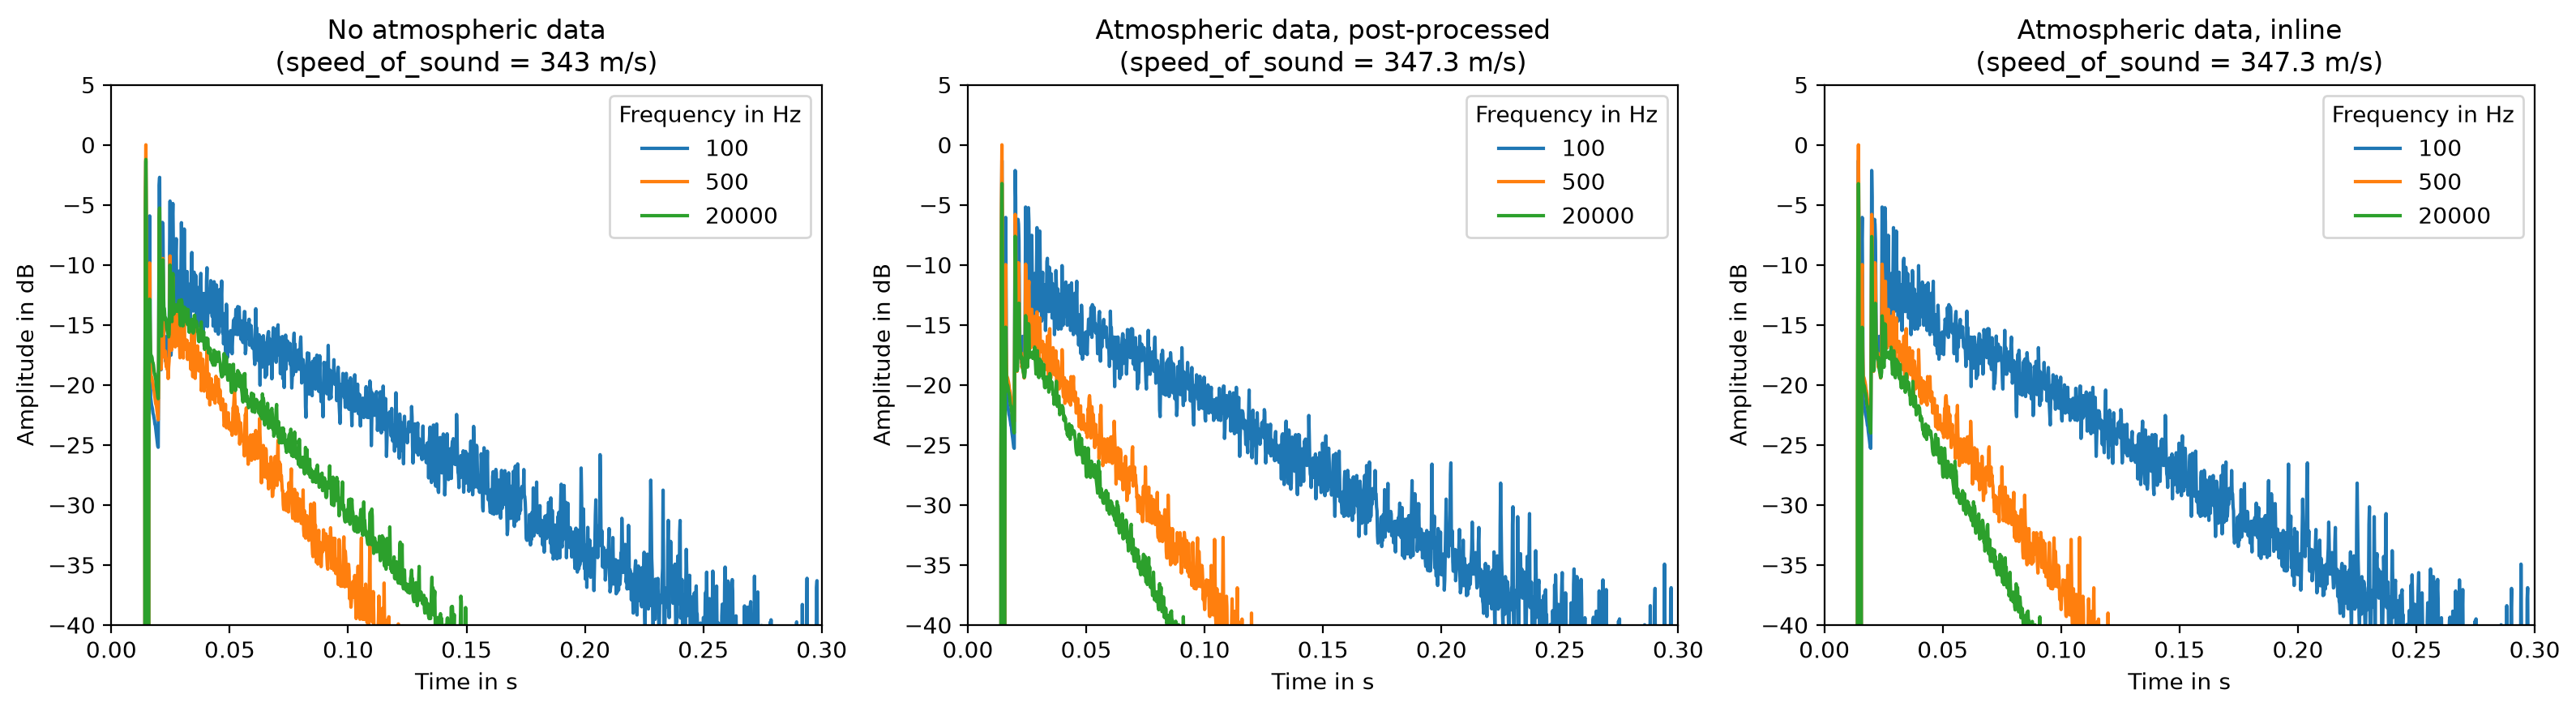

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

plt.sca(axes[0])
plot_etc(etc, sampling_rate, max_time, dB=True, normalize=True, bottom=-40)
axes[0].set_title('No atmospheric data\n(speed_of_sound = 343 m/s)')
axes[0].legend(rendered_frequencies, title='Frequency in Hz')

plt.sca(axes[1])
plot_etc(etc_atmo_post, sampling_rate, max_time, dB=True, normalize=True, bottom=-40)
axes[1].set_title('Atmospheric data, post-processed\n(speed_of_sound = %.1f m/s)' % speed_of_sound_atmo)
axes[1].legend(rendered_frequencies, title='Frequency in Hz')

plt.sca(axes[2])
plot_etc(etc_atmo_auto, sampling_rate, max_time, dB=True, normalize=True, bottom=-40)
axes[2].set_title('Atmospheric data, inline\n(speed_of_sound = %.1f m/s)' % speed_of_sound_atmo)
axes[2].legend(rendered_frequencies, title='Frequency in Hz')

plt.tight_layout()
plt.show()

High frequencies decay noticeably faster once atmospheric attenuation is applied — as expected from ISO 9613-1, air absorption grows sharply with frequency. Visually, the post-processed and inline renderings look very similar, since both use the same speed of sound and the same attenuation model; the next plot quantifies how similar.

### Post-processing vs. inline: same speed of sound

Both `etc_atmo_post` and `etc_atmo_auto` use the *same* speed of sound (`speed_of_sound_atmo`), so a direct, bin-by-bin relative difference is meaningful here — no time-axis alignment is needed. We also isolate the effect of attenuation alone by comparing the un-attenuated raw rendering (`etc_atmo_post_raw`) against the inline-attenuated one.

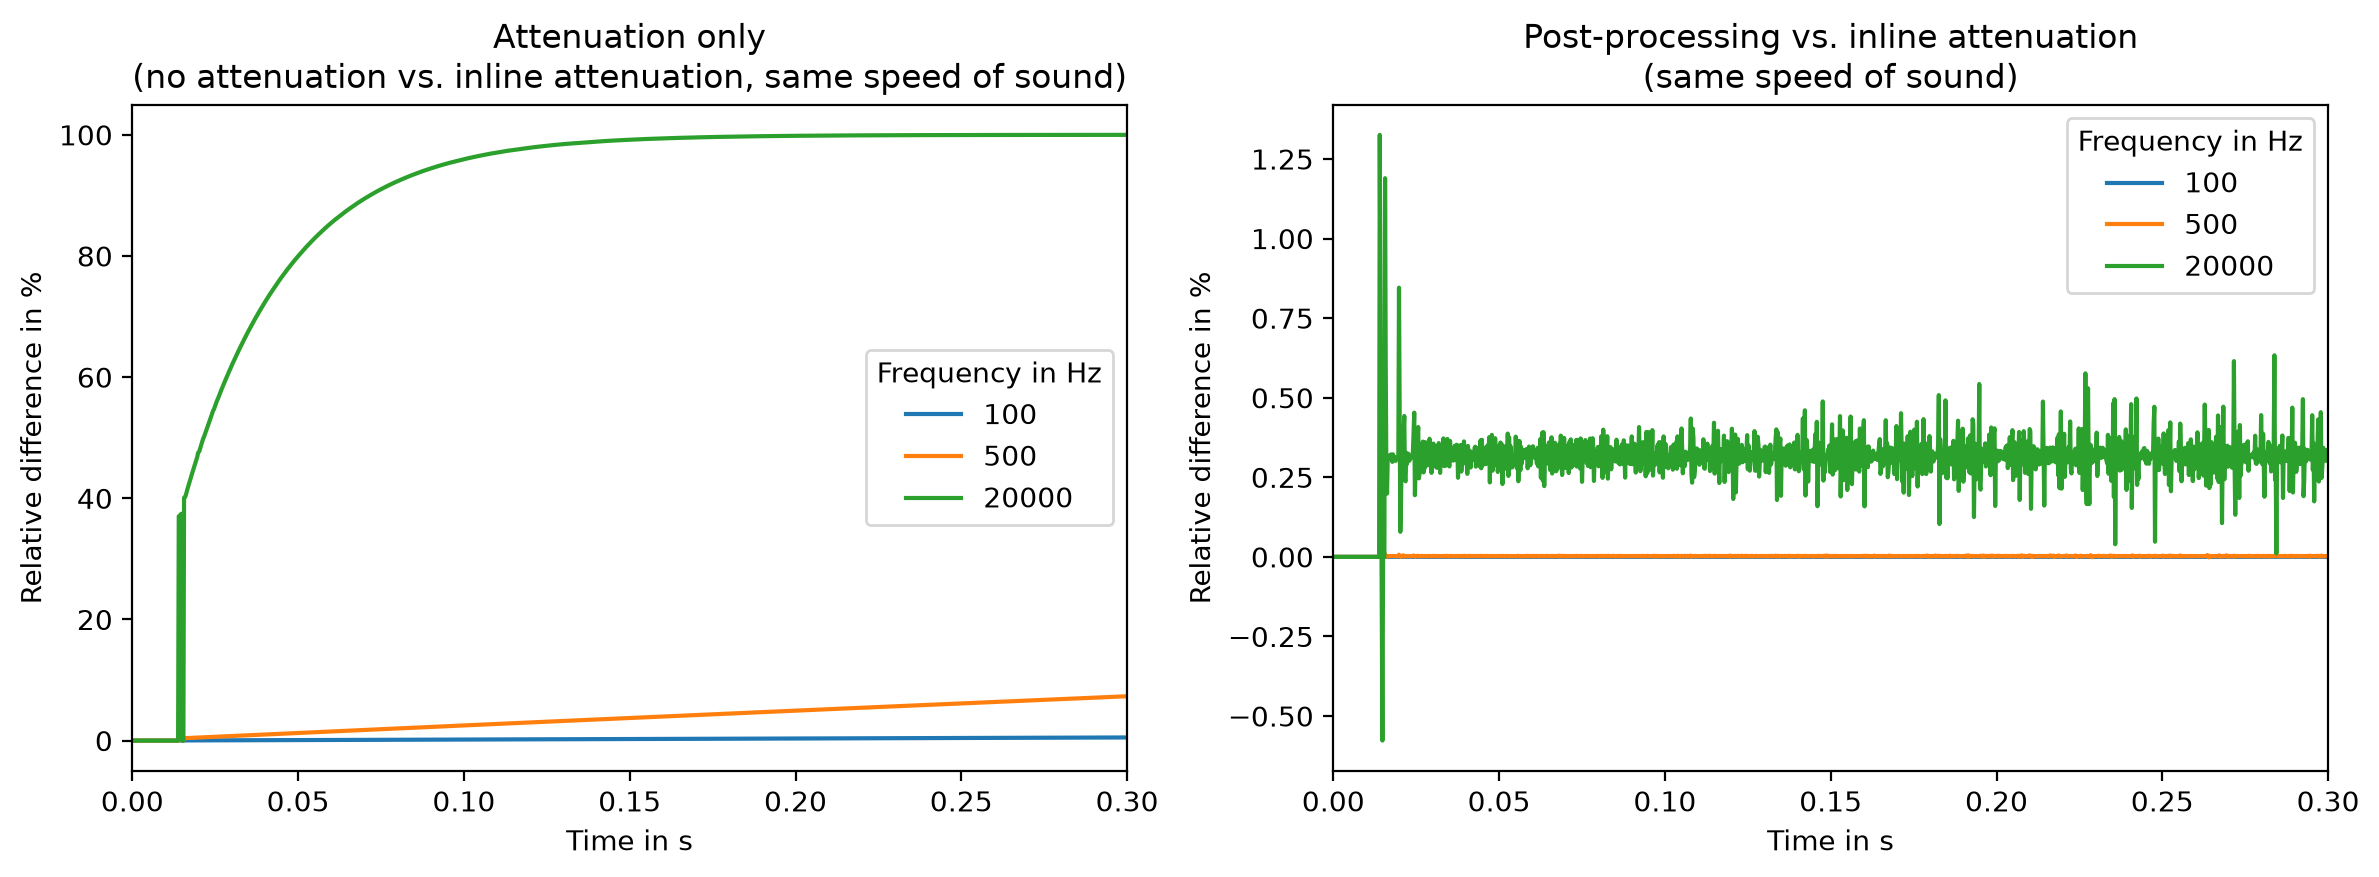

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plt.sca(axes[0])
plot_etc_diff_relative(etc_atmo_post_raw, etc_atmo_auto, sampling_rate, max_time)
axes[0].set_title('Attenuation only\n(no attenuation vs. inline attenuation, same speed of sound)')
axes[0].legend(rendered_frequencies, title='Frequency in Hz')

plt.sca(axes[1])
plot_etc_diff_relative(etc_atmo_post, etc_atmo_auto, sampling_rate, max_time)
axes[1].set_title('Post-processing vs. inline attenuation\n(same speed of sound)')
axes[1].legend(rendered_frequencies, title='Frequency in Hz')

plt.tight_layout()
plt.show()

The left panel shows exactly what ISO 9613-1 predicts: attenuation grows smoothly with distance/time and is far stronger at 20 kHz than at 100 Hz or 500 Hz. The right panel shows a small residual difference between the two attenuation *methods* — post-processing derives each bin's distance from `time * speed_of_sound`, while the inline integrator attenuates using each path's true accumulated geometric distance before binning. The two agree closely, with the inline approach being the more physically accurate of the two.

<div class="admonition important alert alert-block alert-warning">

⚠️ **Why not compare directly against the no-atmosphere baseline this way?**

`etc` was rendered at `speed_of_sound = 343` m/s, while `etc_atmo_post`/`etc_atmo_auto` use `speed_of_sound_atmo` (about 347 m/s for the parameters above — roughly 1.25% higher). A different speed of sound does not just shift the ETC in time, it *rescales* it: for the same physical path distance `d`, the arrival time is `t = d / speed_of_sound`, so bin `i` in one curve and bin `i` in the other generally correspond to *different distances*. A naive bin-by-bin relative difference then compares unrelated events, and — since the ETC consists of sparse, sharp peaks rather than a smooth signal — this shows up as large, noisy swings that drown out the (real, but comparatively small at low frequencies) attenuation effect.

</div>

### Comparing across different speeds of sound

To compare the no-atmosphere baseline against an atmospheric rendering fairly, we need to align the two time axes by physical path **distance**, not by raw bin index. For a curve recorded with `speed_of_sound_source`, bin `i` corresponds to distance `d_i = (i / sampling_rate) * speed_of_sound_source`. Given a *target* speed of sound `speed_of_sound_reference`, we ask: which time bin of the source curve, when re-interpreted as a distance, matches distance `d_i = (i / sampling_rate) * speed_of_sound_reference`? Solving `d_i = query_time * speed_of_sound_source` gives the query time, and we linearly interpolate the source curve there. The result is the source curve resampled onto the *reference* curve's distance grid, so both can be compared bin-by-bin.

In [33]:
def resample_to_reference_speed(etc: mi.TensorXf, sampling_rate, speed_of_sound_source, speed_of_sound_reference):
    """Resample an ETC from its own speed-of-sound time axis onto another one.

    Bin `i` of the *reference* axis represents distance
    ``d_i = (i / sampling_rate) * speed_of_sound_reference``. This returns the
    value of `etc` at that same distance, found by linearly interpolating
    along `etc`'s own (distance-consistent) time axis at
    ``query_time = d_i / speed_of_sound_source``. Bins outside the original
    time range are filled with 0 (silence).
    """
    values = etc.numpy().copy().squeeze()
    n_bins = values.shape[0]
    reference_time = np.arange(n_bins) / sampling_rate
    distance = reference_time * speed_of_sound_reference
    query_time = distance / speed_of_sound_source

    resampled = np.empty_like(values)
    for band in range(values.shape[1]):
        resampled[:, band] = np.interp(query_time, reference_time, values[:, band], left=0.0, right=0.0)
    return resampled


etc_atmo_post_aligned = resample_to_reference_speed(
    etc_atmo_post, sampling_rate, speed_of_sound_source=speed_of_sound_atmo, speed_of_sound_reference=343.0)
etc_atmo_auto_aligned = resample_to_reference_speed(
    etc_atmo_auto, sampling_rate, speed_of_sound_source=speed_of_sound_atmo, speed_of_sound_reference=343.0)

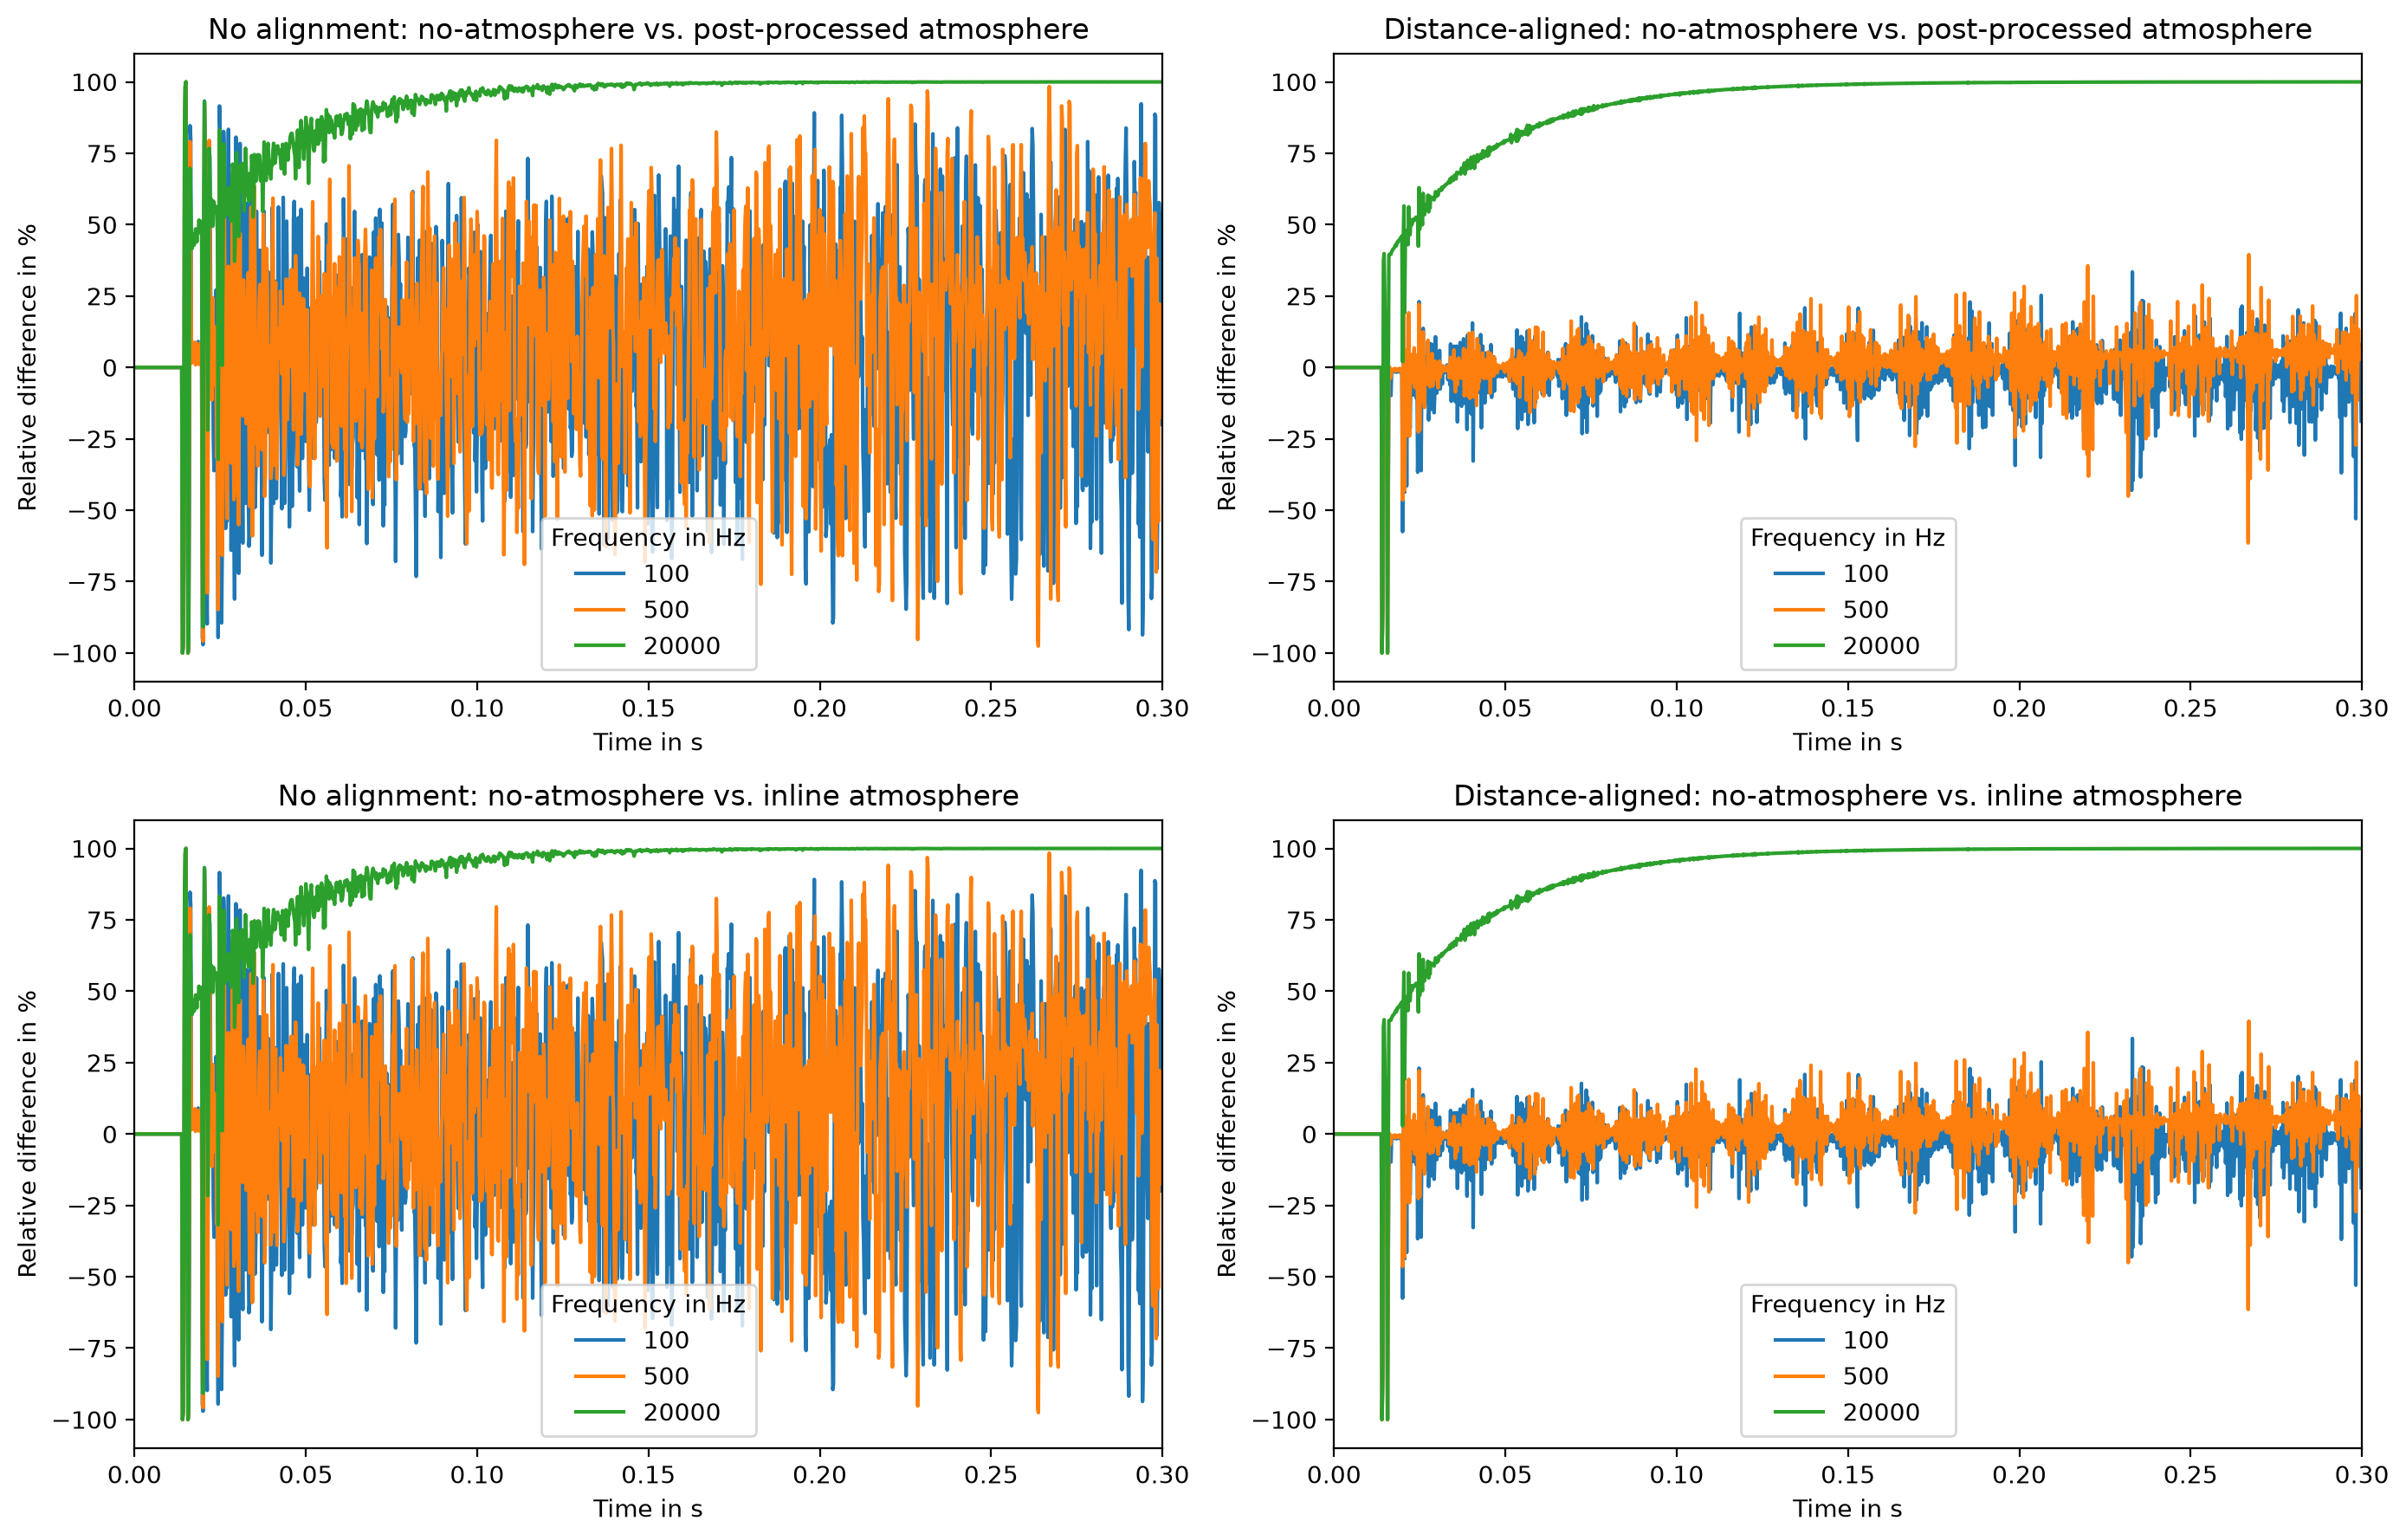

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plt.sca(axes[0][0])
plot_etc_diff_relative(etc, etc_atmo_post, sampling_rate, max_time)
axes[0][0].set_title('No alignment: no-atmosphere vs. post-processed atmosphere')
axes[0][0].legend(rendered_frequencies, title='Frequency in Hz')

plt.sca(axes[0][1])
plot_etc_diff_relative(etc, etc_atmo_post_aligned, sampling_rate, max_time)
axes[0][1].set_title('Distance-aligned: no-atmosphere vs. post-processed atmosphere')
axes[0][1].legend(rendered_frequencies, title='Frequency in Hz')

plt.sca(axes[1][0])
plot_etc_diff_relative(etc, etc_atmo_auto, sampling_rate, max_time)
axes[1][0].set_title('No alignment: no-atmosphere vs. inline atmosphere')
axes[1][0].legend(rendered_frequencies, title='Frequency in Hz')

plt.sca(axes[1][1])
plot_etc_diff_relative(etc, etc_atmo_auto_aligned, sampling_rate, max_time)
axes[1][1].set_title('Distance-aligned: no-atmosphere vs. inline atmosphere')
axes[1][1].legend(rendered_frequencies, title='Frequency in Hz')

plt.tight_layout()
plt.show()

Aligning by distance substantially narrows the noise band at 100 Hz and 500 Hz (their *real* attenuation is small, so before alignment it was completely swamped by the spurious mismatch from the different speeds of sound). The 20 kHz curve barely changes: its attenuation is strong enough that it dominates over the alignment artifact either way, and after alignment it shows the smoothly growing trend predicted by ISO 9613-1, climbing steadily as accumulated path distance increases.

Some residual noise remains even after alignment — the ETC is a sparse, discrete histogram of Monte Carlo path contributions rather than a smooth signal, so individual peaks rarely interpolate perfectly onto a shifted grid. Averaging over a wider window (e.g. octave-band smoothing) would reduce this further, at the cost of time resolution.

## Summary

<div class="admonition important alert alert-block alert-success">

🚀 **Takeaways:**

<ul>
  <li>Post-processing (<code>mi.acoustic.apply_pure_tone_attenuation</code>) and inline rendering (<code>medium</code> + <code>apply_attenuation</code> on <code>acoustic_path</code>) give closely matching results; the inline approach is more accurate since it attenuates using each path's true geometric distance rather than a time-bin-implied one.</li>
  <li>An explicit <code>speed_of_sound</code> on the integrator always takes priority over <code>medium</code>; without it, the integrator derives the speed of sound from <code>medium</code> using <code>speed_method</code>.</li>
  <li>Renderings that used different speeds of sound must be compared on a common <i>distance</i> axis, not a common time-bin index — otherwise the comparison is dominated by a time-axis mismatch rather than the effect you actually want to see.</li>
</ul>

</div>